# **General Analyses of the Network**

In [1]:
import pandas as pd
import numpy as np
import networkx as nx

import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from math import comb

In [2]:
edges = pd.read_csv("../data/edges.csv").rename(columns=lambda x: x.strip())[["# source", "target", "distance"]].drop_duplicates()
nodes = pd.read_csv("../data/nodes.csv").rename(columns=lambda x: x.strip())[["name","city","country","latitude","longitude"]]
nodes = pd.merge(nodes, pd.read_csv("../data/continents.csv"),on="country")

In [3]:
source_airport = np.array(edges["# source"])
destination_airport = np.array(edges["target"])

In [4]:
len(nodes), len(edges)

(3214, 36907)

In [7]:
A = np.array([[0 for i in range(3214)] for i in range(3214)])

assert len(source_airport) == len(destination_airport)

for source, target, distance in edges.values:
    A[np.int16(source)][np.int16(target)] = distance


In [8]:
# nx representation (10 seconds)

G = nx.from_numpy_array(A, create_using=nx.DiGraph) # Undirected!

# **Hustota siete**

In [5]:
len(edges)/comb(len(nodes),2)/2

0.003573980238572647

In [53]:
len(edges)

36907

In [9]:
nx.density(G)
# Dosť nízka, niečo nad 0.3 %
# Koniec koncov, napriamo sa vieme dostať iba do cca 0.35 % dvojíc
# Dosť podobné čísla, má to spojitosť?

0.0035738834011098735

In [10]:
nx.transitivity(G)

0.25005448521436646

# **Počet komponent súvislosti**

In [9]:
nx.number_connected_components(G.to_undirected())

7

In [10]:
for component in nx.connected_components(G.to_undirected()):
    #print(100*len(component)/3214)
    print(component)

# ale je tu komponent, ktorý tvorí 99.19 % !!!

# Tieto malé:

# {931, 932, 933, 934, 935, 936, 937, 2535, 2537, 2536} -> Nová Kaledónia + Brazília
# {2426, 2971, 1837, 2970} -> USA
# {3023, 2643, 3022, 1903} -> rural USA
# {2072, 2300} -> Kanada
# {2259, 3116} -> Grónsko
# {2905, 3097, 2380, 2382} -> Namíbia

# Čiže už vo všeobecnosti možno očakávať vysokú prepojenosť

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [37]:
# Zoradenie komponentov podľa veľkosti
components = sorted(nx.connected_components(G.to_undirected()), key=len, reverse=True)


# Veľkosť obrej komponenty
giant_size = len(components[0])
print(f"Obria komponenta obsahuje {giant_size} letísk ({100 * giant_size / len(G):.2f}% siete)")

# Čo sú tie ostatné?
for i, comp in enumerate(components[1:], 1):
    print(f"Ostrov {i} (veľkosť {len(comp)}): {nodes.loc[list(comp),"country"].values.tolist()}")

Obria komponenta obsahuje 3188 letísk (99.19% siete)
Ostrov 1 (veľkosť 10): ['New Caledonia', 'New Caledonia', 'New Caledonia', 'New Caledonia', 'New Caledonia', 'New Caledonia', 'New Caledonia', 'New Caledonia', 'New Caledonia', 'New Caledonia']
Ostrov 2 (veľkosť 4): ['United States', 'United States', 'United States', 'United States']
Ostrov 3 (veľkosť 4): ['United States', 'United States', 'United States', 'United States']
Ostrov 4 (veľkosť 4): ['Namibia', 'Namibia', 'Namibia', 'Namibia']
Ostrov 5 (veľkosť 2): ['Canada', 'Canada']
Ostrov 6 (veľkosť 2): ['Greenland', 'Greenland']


In [43]:
# Extrakcia obrej komponenty
giant_component_nodes = max(nx.connected_components(G.to_undirected()), key=len)
G_giant = G.subgraph(giant_component_nodes).copy()

print(f"Obrí komponent: {len(G_giant.nodes())} uzlov")

Obrí komponent: 3188 uzlov


In [45]:
avg_clust = nx.average_clustering(G_giant.to_undirected())
avg_path = nx.average_shortest_path_length(G_giant.to_undirected())
print(f"Clustering: {avg_clust:.4f}, Path Length: {avg_path:.2f}")

Clustering: 0.4928, Path Length: 3.96


# **Stupne vrcholov**

In [65]:
degree_dict = dict(nx.degree(G))
degrees = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
nodes["degree"] = nodes.index.map(degree_dict)
len(nodes[nodes["degree"] == min(nodes["degree"])])
one_degree_nodes = nodes[nodes["degree"] == min(nodes["degree"])]

In [66]:
target_set = set(edges["target"])
one_degree_nodes["way"] = ["in" if idx in target_set else "out" for idx in one_degree_nodes.index]

In [14]:
one_degree_nodes.to_csv("data/one_degree.csv",index_label="index")

In [67]:
degree_sequence = list(degree_dict.values())

print(f"Priemer {np.mean(degree_sequence)}")
print(f"Medián {np.median(degree_sequence)}")
print(f"Min {np.min(degree_sequence)}")
print(f"Max {np.max(degree_sequence)}") # Frankfurt am Main Airport	

Priemer 22.965774735532047
Medián 6.0
Min 1
Max 477


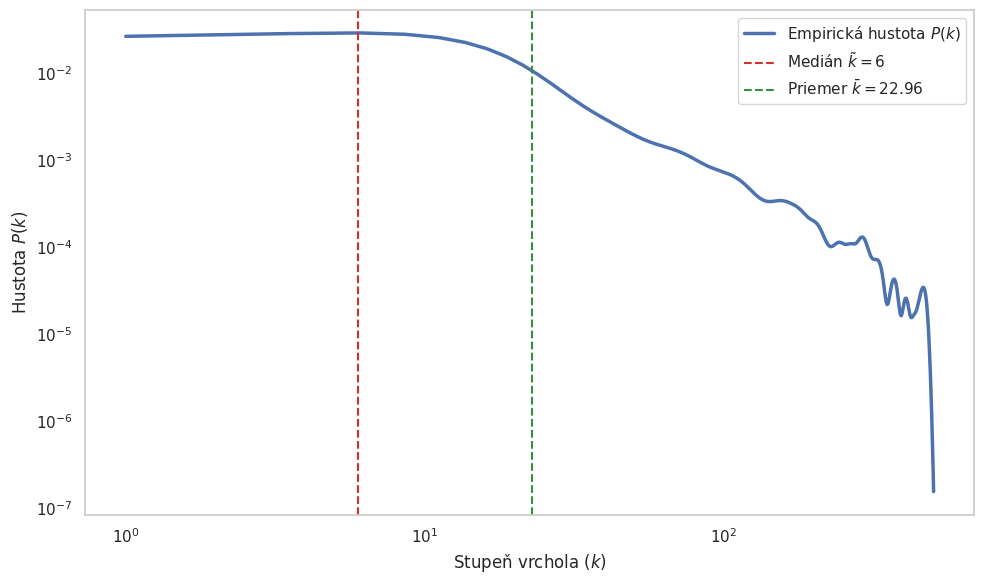

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Nastavenie estetiky (whitegrid pôsobí v odborných prácach najlepšie)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6), dpi=100)

# 2. KDE plot s jemnou výplňou a výraznejšou čiarou
# clip=(1, None) zabezpečí, že logaritmus nebude šalieť pri nulových hodnotách
sns.kdeplot(
    degree_sequence, 
    linewidth=2.5, 
    label="Empirická hustota $P(k)$",
    clip=(1, None) 
)

# 3. Vertikálne línie s lepším kontrastom a LaTeX popiskami
plt.axvline(x=6, color="#D32F2F", linestyle="--", linewidth=1.5, label=r"Medián $\tilde{k} = 6$")
plt.axvline(x=22.96, color="#388E3C", linestyle="--", linewidth=1.5, label=r"Priemer $\bar{k} = 22.96$")

# 4. Formátovanie osí a log-log transformácia
plt.xscale('log')
plt.yscale('log')

# Pridáme pomocnú mriežku pre minoritné hodnoty (v log mierke veľmi dôležité)
plt.grid(False)

# 5. Popisy s použitím LaTeX syntaxe
plt.xlabel(r"Stupeň vrchola ($k$)", fontsize=12)
plt.ylabel(r"Hustota $P(k)$", fontsize=12)

# 6. Legenda a finálne úpravy
plt.legend(frameon=True, facecolor="white", loc="upper right")
plt.tight_layout()

# Uloženie pre LaTeX (odporúčam PDF alebo PNG s vysokým DPI)
# plt.savefig("images/degree_distr_final.png", bbox_inches='tight', dpi=300)
plt.show()

In [11]:
avg_clustering = nx.average_clustering(G.to_undirected())
print(f"Priemerný clustering coefficient: {avg_clustering:.4f}")

Priemerný clustering coefficient: 0.4918
